In [64]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [21]:
# load in all corr means and all corr standard deviations
with open("results/all_corr_means.pkl", 'rb') as f:
    corr_means = pickle.load(f)
    
with open("results/all_corr_standard_deviations.pkl", 'rb') as f:
    corr_stds = pickle.load(f)
    
demo_data = pd.read_csv("/home/zachkaras/fmri/fmri_model/master-survey-data.csv")

def nested_dict():
        return defaultdict(nested_dict)

In [37]:
(np.where(demo_data['id'] == 111))[0][0]

5

In [76]:
# dictionary structure is participant, task, model, layer

# RQ1 - how do correlation values relate to coding performance? Collect correlation values for each participant
participant_performance = defaultdict(list)

# RQ2 - how do the model layers (early vs. late) relate to correlation? For each model, collect correlation values at each layer
layer_performance = nested_dict()

# RQ3 - how do the different models relate to ridge regression performance? Collect correlation values for each model
model_performance = defaultdict(list)

# RQ4 - how do the tasks compare to one another? Collect correlation values for the two tasks
task_performance = defaultdict(list)

for person, taskModelLayerCorr in corr_means.items():
    for task, modelLayerCorr in taskModelLayerCorr.items():
        # if task == 'prose':
        #     continue
        for model,layerCorr in modelLayerCorr.items():
            for layer,corr in layerCorr.items():
                val = corr_means[person][task][model][layer]
                
                participant_performance[person].append(val)    
                model_performance[model].append(val)
                task_performance[task].append(val)
                
                if layer not in layer_performance[model].keys():
                    layer_performance[model][layer] = [val]
                else:
                    layer_performance[model][layer].append(val)


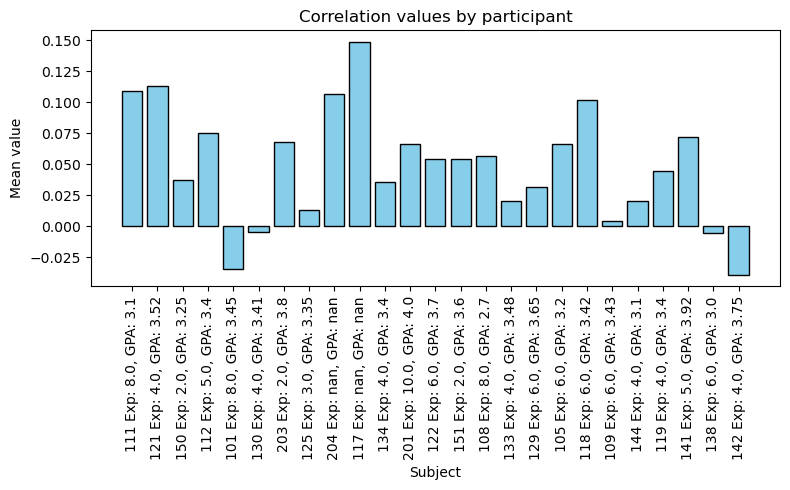

In [59]:
# RQ1 - how do correlation values relate to coding performance? Collect correlation values for each participant
def participant_index(id):
    # idx = (np.where(demo_data['id'] == int(id)))[0]
    # print(id, idx)
    return (np.where(demo_data['id'] == int(id)))[0][0]

# Compute means
labels = list(participant_performance.keys())
labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]
means = [np.mean(v) for v in participant_performance.values()]

# Plot
plt.figure(figsize=(8,5))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("Subject")
plt.xticks(rotation=90)
plt.title("Correlation values by participant")
plt.tight_layout()
plt.show()

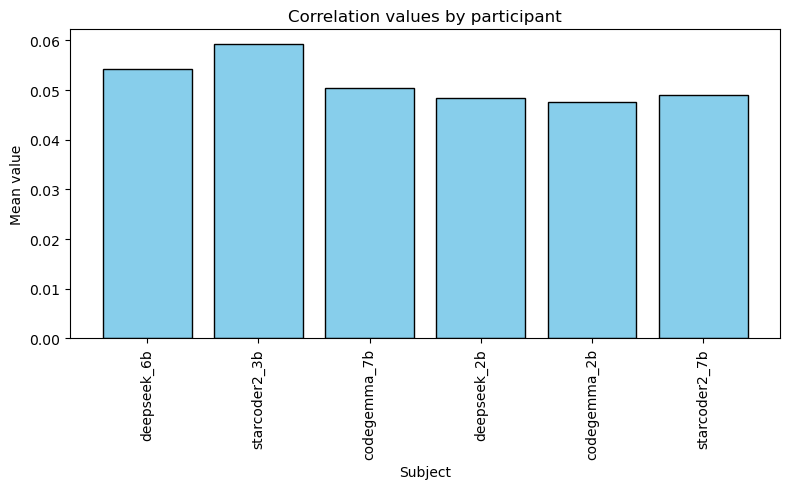

In [60]:
# RQ3 - how do the different models relate to ridge regression performance? Collect correlation values for each model

# Compute means
labels = list(model_performance.keys())
# labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]
means = [np.mean(v) for v in model_performance.values()]

# Plot
plt.figure(figsize=(8,5))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("Subject")
plt.xticks(rotation=90)
plt.title("Correlation values by participant")
plt.tight_layout()
plt.show()

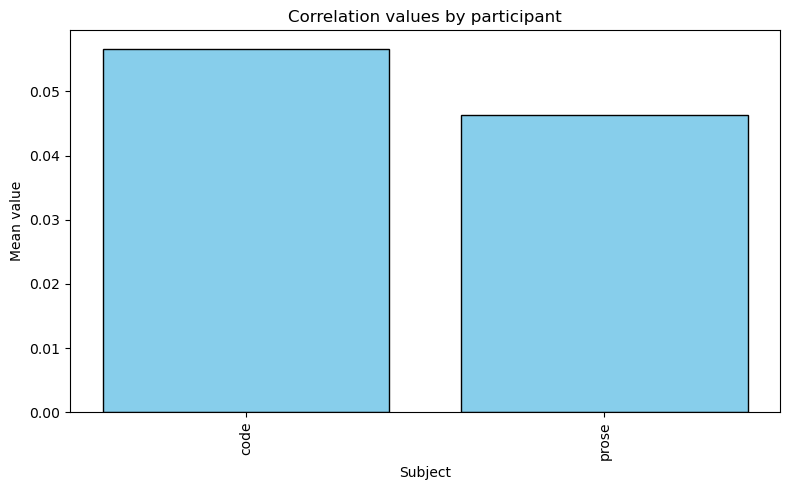

In [61]:
# RQ4 - how do the tasks compare to one another? Collect correlation values for the two tasks

# Compute means
labels = list(task_performance.keys())
# labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]
means = [np.mean(v) for v in task_performance.values()]

# Plot
plt.figure(figsize=(8,5))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("Subject")
plt.xticks(rotation=90)
plt.title("Correlation values by participant")
plt.tight_layout()
plt.show()

In [78]:
layer_performance = json.loads(json.dumps(layer_performance))
layer_performance['starcoder2_3b']

{'layer_0': [0.2126287173246351,
  0.0449741285567989,
  0.10469314585773193,
  0.19625572348660655,
  0.002389748893419538,
  0.04649351547761367,
  0.02306436142928442,
  0.12786356611692476,
  -0.050573004737589015,
  -0.009633523982712024,
  0.08199575986763247,
  0.05085148543570027,
  0.02495726944820687,
  0.020073582980187993,
  0.15150670269367073,
  0.08490700999132281,
  0.14329333779633133,
  0.11876577909559465,
  0.005408472426420802,
  0.053916965884584535,
  0.09967007077337242,
  0.050364549808121085,
  0.05133653472806017,
  0.07571240912326681,
  -0.012368132645067769,
  0.1082304656969464,
  0.06432770821148225,
  0.05809247169623356,
  0.05151671952206192,
  0.03405001065574527,
  0.07624847528217135,
  -0.0025757574678163505,
  0.08326022499682206,
  0.07029996649485609,
  0.1840444037055227,
  0.06813095861559718,
  0.0007032371588006702,
  0.009473629071546075,
  0.0045670769316511345,
  0.0727135425431675,
  0.06007792200259762,
  0.04445546755041884,
  0.12844

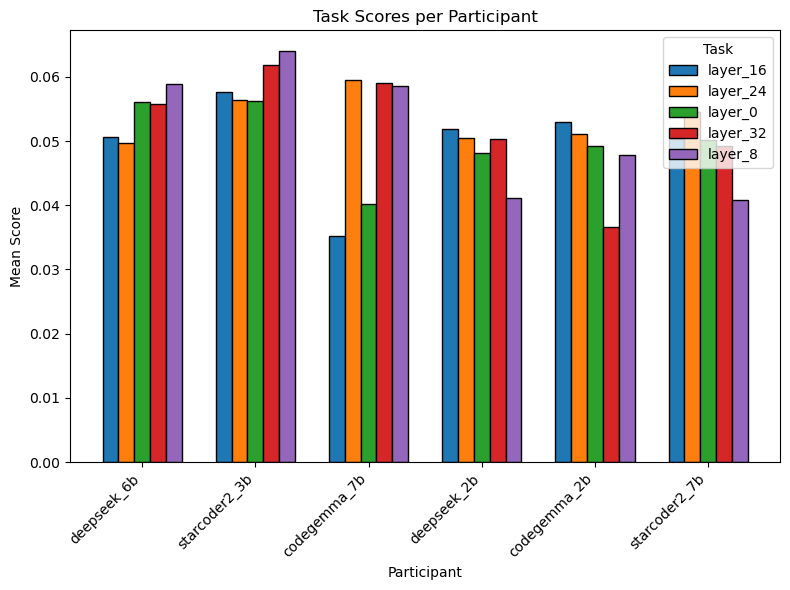

In [80]:
layer_performance = json.loads(json.dumps(layer_performance))

models = list(layer_performance.keys())
layers = list(next(iter(layer_performance.values())).keys())  # assume all participants have same tasks

# Compute means
# means = {p: [np.mean(data[p][t]) for t in tasks] for p in participants}
means = {}
for model, layerScores in layer_performance.items():
    for layer,scores in layerScores.items():
        if model not in means.keys():
            means[model] = [np.mean(scores)]
        else:
            # print(model, layer, scores)
            means[model].append(np.mean(scores))
            
# means = {m: [layer_performance[m][l] for l in layers] for m in models}

# Plot grouped bars
x = np.arange(len(models))  # positions for participants
width = 0.35 / len(layers) * 2     # adjust width depending on number of tasks

plt.figure(figsize=(8,6))
for i, layer in enumerate(layers):
    plt.bar(x + i*width, [means[m][i] for m in models],
            width, label=layer, edgecolor='black')

plt.xlabel("Participant")
plt.ylabel("Mean Score")
plt.title("Task Scores per Participant")
plt.xticks(x + width*(len(layers)-1)/2, models, rotation=45, ha='right')
plt.legend(title="Task")
plt.tight_layout()
plt.show()